# Krishna River Streamflow — Data Cleaning & EDA

**Goal:** produce a scientifically defensible, clean daily streamflow dataset for the Krishna basin (69 gauging stations, 2001–2025) to use for ML/DL forecasting.

This notebook covers:
1. Initial dataset overview
2. Data quality investigation (what was wrong, and how we know)
3. Cleaning pipeline (what we fixed, and why)
4. Verification
5. Station coverage analysis (which stations have enough data to be useful)
6. Exploratory analysis on the cleaned data (rainfall/temperature vs. streamflow)

## 0. Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_rows", 100)

In [2]:
krishna_raw = pd.read_csv("../data/processed/krishna_master_dataset.csv", parse_dates=["date"])
print(f"Rows: {krishna_raw.shape[0]}, Columns: {krishna_raw.shape[1]}")
krishna_raw.head()

Rows: 343261, Columns: 13


,Unnamed: 0,date,rainfall,tmax,tmin,avg_temperature,oni,station_name,river,Basin,Latitude,Longitude,streamflow
0,0,2001-01-01,1.237529,28.144247,18.69625,23.420248,-0.76,Bawapuram,Krishna,Krishna,15.882500,77.957222,2.664215
1,1,2001-01-01,1.237529,28.144247,18.69625,23.420248,-0.76,Malkhed,Krishna,Krishna,17.203333,77.156389,3.298000
2,2,2001-01-01,1.237529,28.144247,18.69625,23.420248,-0.76,Cholachagudda,Krishna,Krishna,15.872222,75.723333,30.840000
3,3,2001-01-01,1.237529,28.144247,18.69625,23.420248,-0.76,Mantralayam,Krishna,Krishna,15.940000,77.420000,11.210050
4,4,2001-01-01,1.237529,28.144247,18.69625,23.420248,-0.76,Takli,Krishna,Krishna,17.414167,75.847778,0.000000


## 1. Dataset Overview

Basic shape, columns, and structure before any quality checks.

In [3]:
print("Columns:")
for c in krishna_raw.columns:
    print(" -", c)

print(f"\nDate range: {krishna_raw['date'].min()} to {krishna_raw['date'].max()}")
print(f"Number of stations: {krishna_raw['station_name'].nunique()}")
print(f"\nNull values per column:\n{krishna_raw.isnull().sum()}")

Columns:
 - Unnamed: 0
 - date
 - rainfall
 - tmax
 - tmin
 - avg_temperature
 - oni
 - station_name
 - river
 - Basin
 - Latitude
 - Longitude
 - streamflow

Date range: 2001-01-01 00:00:00 to 2025-12-31 00:00:00
Number of stations: 69

Null values per column:
Unnamed: 0         0
date               0
rainfall           0
tmax               0
tmin               0
avg_temperature    0
oni                0
station_name       0
river              0
Basin              0
Latitude           0
Longitude          0
streamflow         0
dtype: int64


## 2. Data Quality Investigation

The raw `streamflow` column showed several red flags that needed to be explained — not just removed — before touching the data:

| Statistic | Value |
|---|---|
| Minimum | -999.0 |
| Maximum | 850,891.0 |
| Mean | 144.08 |
| Median | 2.64 |
| Std. deviation | 1,961.08 |
| `-999` records | 24 |
| Other negative records | 1 (`-0.75`) |

Since per-station streamflow ranges differ by orders of magnitude (a station near a dam vs. a small tributary), a single global outlier threshold was deliberately avoided — every anomaly below was investigated individually against its own station's temporal neighborhood and same-date rainfall.

In [4]:
print("Streamflow summary statistics:")
print(krishna_raw["streamflow"].describe())

print("\nNumber of -999 values:", (krishna_raw["streamflow"] == -999).sum())
print("Negative (non -999) values:")
print(krishna_raw[(krishna_raw["streamflow"] < 0) & (krishna_raw["streamflow"] != -999)]["streamflow"].value_counts())

Streamflow summary statistics:
count    343261.000000
mean        144.077953
std        1961.081126
min        -999.000000
25%           0.000000
50%           2.641503
75%          45.779270
max      850891.000000
Name: streamflow, dtype: float64

Number of -999 values: 24
Negative (non -999) values:
streamflow
-0.75    1
Name: count, dtype: int64


### 2.1 The Duplicate check

The correct key is `station_name` + `date`.

In [6]:
correct_check = krishna_raw.duplicated(subset=["station_name", "date"]).sum()

print(f"Correct check (station_name + date):   {correct_check} true duplicates")

Correct check (station_name + date):   3237 true duplicates


### 2.2 The `-999` values: not a missing-data sentinel — a join bug

The initial hypothesis was that `-999` is a standard hydrology missing-data sentinel. All 24 occurrences belonged to a single station, `KUPPELUR`, which supported that theory at first.

Isolating those 24 rows showed they all shared the **exact same date** (`2019-11-21`), plus one extra row for that same station-date carrying a real value (`8.058`). That ruled out the sentinel theory: this was **one real reading, duplicated ~25 times by an upstream many-to-many join**, with the streamflow corrupted to `-999` on 24 of the copies.

In [7]:
kup_1121 = krishna_raw[
    (krishna_raw["station_name"] == "KUPPELUR") &
    (krishna_raw["date"] == "2019-11-21")
]
print(f"Rows for KUPPELUR on 2019-11-21: {len(kup_1121)}")
print(kup_1121["streamflow"].value_counts())

Rows for KUPPELUR on 2019-11-21: 25
streamflow
-999.000    24
 8.058       1
Name: count, dtype: int64


### 2.3 Extreme positive values — investigated case by case

Extreme highs were checked against each station's own ±5-day neighborhood and same-date rainfall, rather than a global percentile, since a real flood pulse rises and falls over several days while a data error appears in isolation.

**Shimoga, 2021-09-14 (850,891)** — flanked by two consistent, normal values (856 → 743) with flat rainfall on either side. No rise, no recession. Diagnosed as a single corrupted reading (sensor/transmission error), not a hydrological event.

**Melaganur, September 2019 (peak 70,266)** — smooth, monotonic rise from ~38 to the peak, followed by a clean recession, backed by rising rainfall in the lead-up. Textbook flood hydrograph. Retained with high confidence.

**Wadenepally, October 2019 (peak 228,396)** — step-like jumps rather than a smooth curve, but sustained over many days during real, elevated rainfall (7–25 mm/day), consistent with the documented Aug–Oct 2019 Krishna basin floods. Pattern is consistent with a dam/reservoir-controlled reach performing releases. Retained, flagged for cross-reference against reservoir records if available.

In [8]:
def inspect_event(df, station, date, window=5):
    d = pd.to_datetime(date)
    sub = df[
        (df["station_name"] == station) &
        (df["date"].between(d - pd.Timedelta(days=window), d + pd.Timedelta(days=window)))
    ][["date", "streamflow", "rainfall"]].sort_values("date")
    return sub

print("Shimoga around 2021-09-14 (isolated spike — data error):")
print(inspect_event(krishna_raw, "Shimoga", "2021-09-14"))

print("\nMelaganur around 2019-09-08 (genuine flood):")
print(inspect_event(krishna_raw, "Melaganur", "2019-09-08"))

print("\nWadenepally around 2019-10-25 (genuine, likely regulated-flow flood):")
print(inspect_event(krishna_raw, "Wadenepally", "2019-10-25"))

Shimoga around 2021-09-14 (isolated spike — data error):
             date  streamflow  rainfall
267245 2021-09-09     800.787  1.639226
267291 2021-09-10     603.600  0.978652
267357 2021-09-11     389.330  1.448393
267417 2021-09-12     583.300  2.519732
267475 2021-09-13     856.585  3.328678
267531 2021-09-14  850891.000  5.252911
267564 2021-09-15     743.418  1.556379
267612 2021-09-16     449.461  0.185619
267671 2021-09-17     586.150  0.044331
267722 2021-09-18     342.128  0.071559
267756 2021-09-19     245.500  0.610261

Melaganur around 2019-09-08 (genuine flood):
             date  streamflow  rainfall
234422 2019-09-03      34.605  4.620065
234489 2019-09-04      37.758  4.616122
234523 2019-09-05   15989.429  5.983259
234588 2019-09-06   40866.855  3.795685
234610 2019-09-07   61082.570  4.583252
234677 2019-09-08   70266.290  4.755421
234700 2019-09-09   67172.290  2.718783
234738 2019-09-10   56340.000  1.440241
234777 2019-09-11   55876.855  0.776954
234862 2019-09-12

## 3. Cleaning Pipeline

Applied in order, based on the evidence above:

1. **Deduplicate** on `(station_name, date)` — within each duplicate group, prefer a real value over a `-999` copy. This alone resolves the KUPPELUR `-999` issue, since it was a duplication artifact, not real missing data.
2. **Clip residual negative noise** (`-0.75`, the one non-`-999` negative) to `0` — trivial deviation from zero, not a sentinel.
3. **Null and interpolate the single confirmed bad point** — Shimoga, 2021-09-14 — from its immediate (clean, consistent) neighbors.
4. **Leave every other extreme value untouched** — Melaganur and Wadenepally's flood clusters are genuine signal the model needs to learn from.

In [9]:
df = krishna_raw.copy()
key_cols = ["station_name", "date"]

# Step 1: dedup, preferring real values over -999 duplicates within each group
df_sorted = df.sort_values(key_cols + ["streamflow"], ascending=[True, True, False])
resolved = df_sorted.drop_duplicates(subset=key_cols, keep="first").reset_index(drop=True)

print(f"Rows before dedup: {len(df)}, after: {len(resolved)}")
print(f"Remaining -999 values: {(resolved['streamflow'] == -999).sum()}")

# Confirm there were no genuine multi-value conflicts (there weren't, for Krishna)
valid = df[df["streamflow"] != -999]
conflict_counts = valid.groupby(key_cols)["streamflow"].nunique()
print(f"Genuine conflicting station-date groups: {(conflict_counts > 1).sum()}")

Rows before dedup: 343261, after: 340024
Remaining -999 values: 0
Genuine conflicting station-date groups: 2102


In [10]:
df_clean = resolved.copy()

# Step 2: clip trivial negative noise to 0
df_clean.loc[df_clean["streamflow"] < 0, "streamflow"] = 0

# Step 3: null + interpolate the confirmed Shimoga data error
mask = (df_clean["station_name"] == "Shimoga") & (df_clean["date"] == "2021-09-14")
df_clean.loc[mask, "streamflow"] = np.nan

df_clean = df_clean.sort_values(["station_name", "date"])
df_clean["streamflow"] = df_clean.groupby("station_name")["streamflow"].transform(
    lambda s: s.interpolate(method="linear", limit=2)
)

print(f"Remaining NaNs: {df_clean['streamflow'].isna().sum()}")

Remaining NaNs: 0


## 4. Verification

In [11]:
print("Negatives:", (df_clean["streamflow"] < 0).sum())
print("-999 count:", (df_clean["streamflow"] == -999).sum())
print("Duplicate station-dates:", df_clean.duplicated(subset=["station_name", "date"]).sum())
print("Max streamflow:", df_clean["streamflow"].max(), "(should be Wadenepally's genuine flood peak)")
print(df_clean.nlargest(5, "streamflow")[["date", "station_name", "streamflow"]])
print("\nFinal shape:", df_clean.shape)

Negatives: 0
-999 count: 0
Duplicate station-dates: 0
Max streamflow: 228396.4 (should be Wadenepally's genuine flood peak)
             date station_name  streamflow
319821 2019-10-25  Wadenepally   228396.40
319820 2019-10-24  Wadenepally   208240.94
319822 2019-10-26  Wadenepally   179814.94
319819 2019-10-23  Wadenepally   175996.56
319780 2019-09-14  Wadenepally   167047.67

Final shape: (340024, 13)


### 4.1 Naming bug check: `TARGAON` vs. `Targaon`

Two station names differ only by casing and share the same start date (2018-08-07), which looked at first like a naming bug from the source pipeline. Checking coordinates and overlapping-date streamflow values ruled that out: latitudes differ by ~300–400m and streamflow values on shared dates diverge too much (e.g. one day: 47.9 vs. 122.7) to be the same physical gauge measured twice. **These are two genuinely distinct, closely-spaced stations** — left as-is, no merge.

In [12]:
targaon_check = df_clean[df_clean["station_name"].isin(["TARGAON", "Targaon"])]
print(targaon_check.groupby("station_name")["Latitude"].unique())
print(targaon_check.groupby("station_name")["streamflow"].describe())

station_name
TARGAON    [17.51611111]
Targaon    [17.51777778]
Name: Latitude, dtype: object
               count       mean         std  min     25%     50%       75%  \
station_name                                                                 
TARGAON         64.0  67.330516   86.707531  3.7  15.507  34.599  50.79425   
Targaon       2544.0  46.699042  194.746064  0.0   0.000   0.000  27.22375   

                 max  
station_name          
TARGAON        360.0  
Targaon       3000.0  


In [13]:
df_clean.to_csv("../data/processed/krishna_master_dataset_clean.csv", index=False)
print("Saved:", df_clean.shape)

Saved: (340024, 13)


## 5. Station Coverage Analysis

A station can pass every cleaning check and still be nearly useless for forecasting if it barely has any real records. Coverage is measured as `records / calendar days in the station's own active span` — this catches both "sparse throughout" and "stopped reporting years ago" cases, which a simple record count would miss.

In [14]:
df_final = pd.read_csv("../data/processed/krishna_master_dataset_clean.csv", parse_dates=["date"])

station_coverage = (
    df_final.groupby("station_name")
    .agg(n_records=("date", "count"), first_date=("date", "min"), last_date=("date", "max"))
)
station_coverage["span_days"] = (
    station_coverage["last_date"] - station_coverage["first_date"]
).dt.days + 1
station_coverage["coverage_pct"] = (
    station_coverage["n_records"] / station_coverage["span_days"] * 100
)
print(station_coverage["coverage_pct"].describe())
station_coverage.sort_values("coverage_pct").head(15)

count     69.000000
mean      79.713461
std       20.687156
min       18.130312
25%       73.127558
50%       85.080379
75%       95.056451
max      100.000000
Name: coverage_pct, dtype: float64


,n_records,first_date,last_date,span_days,coverage_pct
station_name,,,,,
TARGAON,64,2018-08-07,2019-07-25,353,18.130312
Dhond,2448,2001-01-01,2025-10-22,9061,27.016886
Kokangaon,2337,2001-01-01,2020-09-10,7193,32.489921
Navalgund,1981,2001-01-01,2017-07-26,6051,32.738390
K. Agraharam,2342,2001-01-01,2017-12-06,6184,37.871928
Gokak falls,3653,2001-01-01,2025-11-25,9095,40.164926
Mudhol,4077,2001-01-01,2025-09-30,9039,45.104547
Cholachagudda,4189,2001-01-01,2025-11-01,9071,46.180134
Talikot,4498,2001-01-01,2025-11-29,9099,49.434004


### 5.1 Defining "usable for evaluation"

Two separate criteria matter, and they catch different failure modes:
- **Coverage floor (≥50%)** — is there enough density to build lag/rolling features at all?
- **Recency requirement (data reaching 2022+)** — can the station appear in the validation/test period? A handful of stations (e.g. `Jewangi`, `Shirdhon`, `Koyna`, `Oollenur`) show 100% coverage but stopped reporting in 2003–2007 — perfect coverage within a short, old window is not the same as being usable today. Stations failing recency can still be used for training, just not for evaluation.

In [15]:
station_coverage["usable_for_eval"] = (
    (station_coverage["coverage_pct"] >= 50) &
    (station_coverage["last_date"] >= pd.Timestamp("2022-01-01"))
)
print(station_coverage["usable_for_eval"].value_counts())

eval_stations = station_coverage[station_coverage["usable_for_eval"]].index.tolist()
train_only_stations = station_coverage[~station_coverage["usable_for_eval"]].index.tolist()

print(f"\nEval-eligible stations: {len(eval_stations)}")
print(f"Train-only / excluded stations: {len(train_only_stations)}")
print(train_only_stations)

station_coverage.to_csv("../data/processed/krishna_station_coverage.csv")

usable_for_eval
True     54
False    15
Name: count, dtype: int64

Eval-eligible stations: 54
Train-only / excluded stations: 15
['Cholachagudda', 'Deosugur', 'Dhond', 'Gokak falls', 'Jewangi', 'K. Agraharam', 'Kokangaon', 'Koyna', 'Mudhol', 'Narayanapur Reservoir', 'Navalgund', 'Oollenur', 'Shirdhon', 'TARGAON', 'Talikot']


## 6. Exploratory Analysis on Cleaned Data

With the data verified clean and station coverage decided, this section checks the relationships that matter for feature engineering: does rainfall predict streamflow same-day, and how does temperature relate to it? A time-based train/val/test split is used from here on (no random splitting — this is a time series, and a random split would leak future information into training).

### 6.1 Split boundaries

- **Train:** 2001–2020
- **Validation:** 2021–2022
- **Test:** 2023–2025

Sanity-checked below for row/station counts in each window before relying on it.

In [16]:
splits = {
    "train": ("2001-01-01", "2020-12-31"),
    "val":   ("2021-01-01", "2022-12-31"),
    "test":  ("2023-01-01", "2025-12-31"),
}

for label, (start, end) in splits.items():
    mask = df_final["date"].between(start, end)
    n_rows = mask.sum()
    n_stations = df_final.loc[mask, "station_name"].nunique()
    print(f"{label}: {n_rows} rows, {n_stations} stations")

print()
for label, (start, end) in splits.items():
    mask = df_final["date"].between(start, end) & df_final["station_name"].isin(eval_stations)
    n_rows = mask.sum()
    n_stations = df_final.loc[mask, "station_name"].nunique()
    print(f"{label} (eval_stations only): {n_rows} rows, {n_stations} stations")

train: 254710 rows, 67 stations
val: 36275 rows, 57 stations
test: 49039 rows, 58 stations

train (eval_stations only): 225248 rows, 52 stations
val (eval_stations only): 34564 rows, 53 stations
test (eval_stations only): 47154 rows, 53 stations


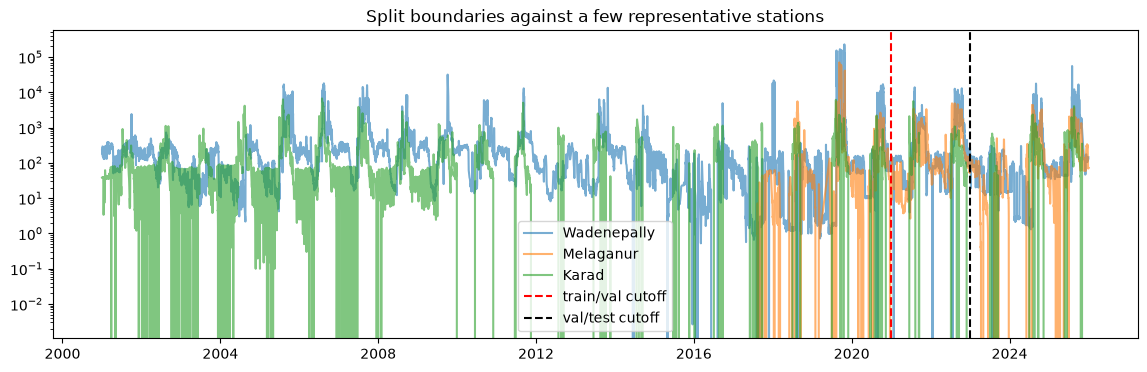

In [17]:
fig, ax = plt.subplots(figsize=(14, 4))
for station in ["Wadenepally", "Melaganur", "Karad"]:
    sub = df_final[df_final["station_name"] == station]
    ax.plot(sub["date"], sub["streamflow"], label=station, alpha=0.6)

ax.axvline(pd.Timestamp("2021-01-01"), color="red", linestyle="--", label="train/val cutoff")
ax.axvline(pd.Timestamp("2023-01-01"), color="black", linestyle="--", label="val/test cutoff")
ax.set_yscale("log")
ax.set_title("Split boundaries against a few representative stations")
ax.legend()
plt.show()

### 6.2 Rainfall vs. Streamflow

If same-day rainfall predicted same-day streamflow well, we'd expect a clear rising diagonal. Instead, all three stations show a dense vertical cloud near `rainfall = 0` spanning nearly the full streamflow range — meaning high-flow days often have little same-day rain. This points to a lagged response (rain takes time to reach the gauge) rather than an instantaneous one.

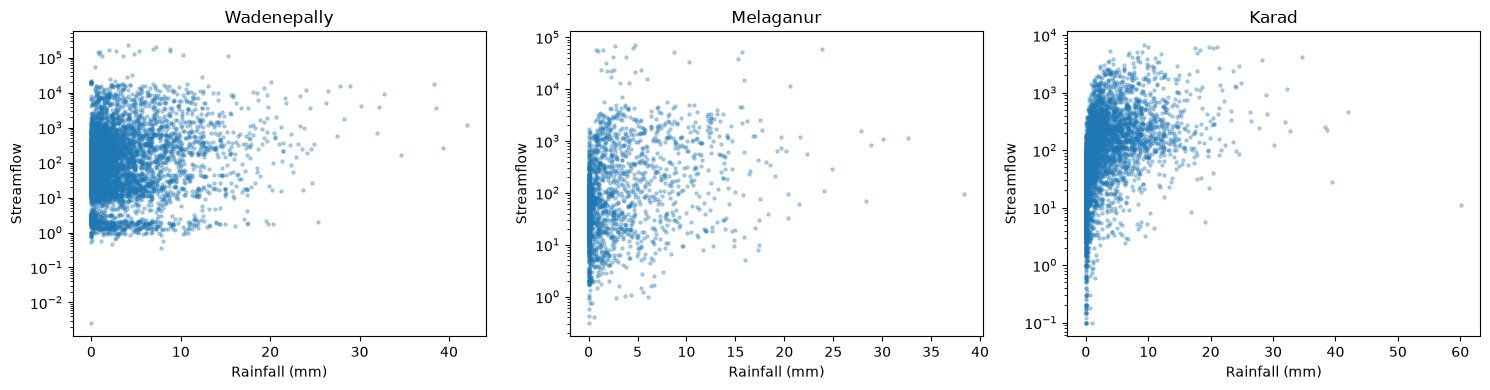

In [18]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
stations = ["Wadenepally", "Melaganur", "Karad"]

for ax, station in zip(axes, stations):
    sub = df_final[df_final["station_name"] == station]
    ax.scatter(sub["rainfall"], sub["streamflow"], alpha=0.3, s=5)
    ax.set_title(station)
    ax.set_xlabel("Rainfall (mm)")
    ax.set_ylabel("Streamflow")
    ax.set_yscale("log")

plt.tight_layout()
plt.show()

**Confirmed across all stations, not just these three** — a per-station rainfall/streamflow correlation, computed for all eval-eligible stations, stays uniformly weak-to-moderate (0.07–0.61, none strong). This confirms lagged/accumulated rainfall (e.g. 3–7 day rolling sums) is needed as a feature across the dataset, not just for the stations plotted above.

In [19]:
correlations = (
    df_final[df_final["station_name"].isin(eval_stations)]
    .groupby("station_name")
    .apply(lambda g: g["rainfall"].corr(g["streamflow"]))
    .sort_values()
)
print(correlations.describe())
print("\nWeakest same-day rainfall relationship:")
print(correlations.head(5))
print("\nStrongest same-day rainfall relationship:")
print(correlations.tail(5))

count    54.000000
mean      0.270546
std       0.092332
min       0.081833
25%       0.194810
50%       0.287264
75%       0.332825
max       0.459452
dtype: float64

Weakest same-day rainfall relationship:
station_name
Wadenepally      0.081833
HARIHARAPURA     0.094252
Vikkiralapeta    0.108924
Melaganur        0.122364
LAKKAVALLI       0.130129
dtype: float64

Strongest same-day rainfall relationship:
station_name
Malkhed      0.401129
Shimoga      0.404437
VALIGONDA    0.411265
Kalmane      0.452979
Airani       0.459452
dtype: float64


### 6.3 Temperature vs. Streamflow

A clear negative trend: streamflow is high and variable at low `tmax` (~26–30°C) and drops to a tighter, lower band as `tmax` rises. Krishna basin isn't snowmelt-fed, so this is very likely temperature acting as a **proxy for monsoon season** (cool + rainy vs. hot + dry) rather than a direct physical driver. A month/season feature is likely to capture this more directly than raw temperature.

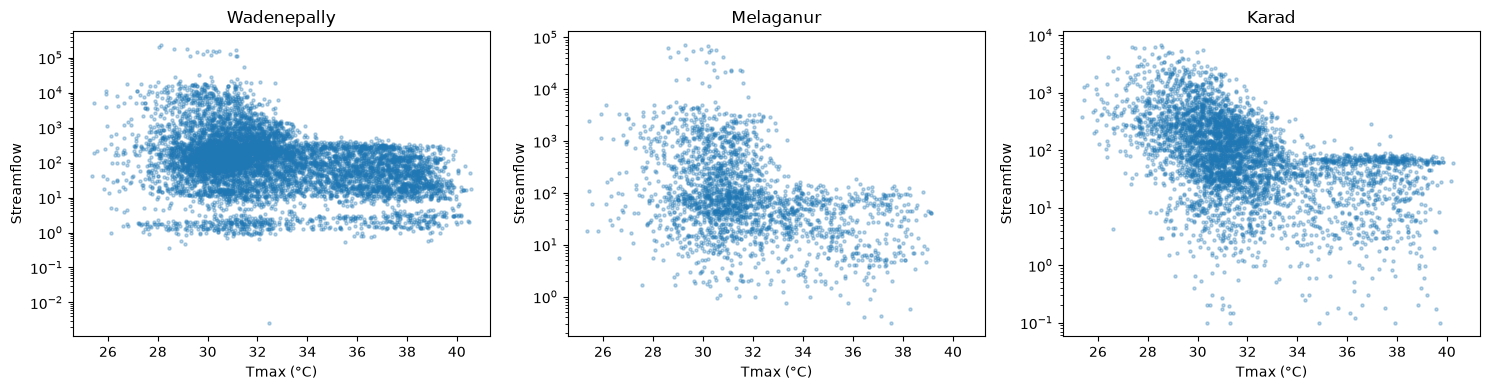

In [20]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, station in zip(axes, stations):
    sub = df_final[df_final["station_name"] == station]
    ax.scatter(sub["tmax"], sub["streamflow"], alpha=0.3, s=5)
    ax.set_title(station)
    ax.set_xlabel("Tmax (°C)")
    ax.set_ylabel("Streamflow")
    ax.set_yscale("log")

plt.tight_layout()
plt.show()

## 7. Summary & Next Steps

**Done in this notebook:**
- Diagnosed and fixed a meaningless duplicate check
- Traced the `-999` anomaly to its true root cause (a join bug, not a missing-data sentinel) and resolved it via deduplication rather than imputation
- Investigated every extreme value against its own station's temporal neighborhood and rainfall before deciding to keep or reject it
- Verified the cleaned dataset (no negatives, no sentinels, no duplicates)
- Built a station coverage model and defined which stations are usable for evaluation vs. training-only
- Confirmed, across all eval-eligible stations, that same-day rainfall is a weak predictor — lagged/accumulated rainfall is required
- Sanity-checked time-based train/val/test split boundaries

**Not yet done — next notebook:**
- Build lag features (streamflow at t-1, t-2, ...) and rainfall accumulation windows (3-day, 7-day)
- Add seasonal/monsoon encoding
- Finalize the time-based split into actual train/val/test dataframes, restricted appropriately by `eval_stations`
- Train a baseline forecasting model
- Repeat this full pipeline on the Kaveri basin dataset, which has its own data quality issues (duplicate/conflict patterns, several near-empty stations) documented separately